# Proyek Analisis Data: Bike Sharing
- **Nama:** Jonathan Christian
- **Email:** cdcc005d6y1403@student.devacademy.id
- **ID Dicoding:** CDCC005D6Y1403

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda per jam selama tahun 2012?
- **Pertanyaan 2:** Pada jam berapa terjadi puncak penyewaan sepeda dalam sehari, dan bagaimana pola tersebut berbeda antara hari kerja dan hari libur?

## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import numpy as np

## Data Wrangling

### Gathering Data

#### Load df ...

In [4]:
df = pd.read_csv("/content/hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)

Dataset menunjukkan bahwa penyewaan sepeda dicatat setiap jam, dengan jumlah yang sangat rendah pada dini hari (jam 0–4). Selain itu, mayoritas pengguna berasal dari registered users dibandingkan casual users, menunjukkan bahwa layanan ini lebih sering digunakan oleh pelanggan tetap. Variabel seperti cuaca, suhu, dan hari kerja juga tersedia, sehingga memungkinkan analisis lebih lanjut terkait faktor-faktor yang memengaruhi jumlah penyewaan.

### Assessing Data

#### Identifying ... problem

In [5]:
df.info()
df.describe()
df.isna().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


np.int64(0)

**Insight:** (Opsional)

Berdasarkan hasil assessing data, diperoleh beberapa insight:

1. Dataset memiliki 17.379 baris dan 17 kolom.
2. Tidak ditemukan missing value pada seluruh kolom.
3. Tidak ditemukan data duplikat.
4. Beberapa kolom seperti 'season' dan 'weathersit' masih dalam bentuk numerik dan perlu dikonversi menjadi kategori agar lebih mudah dipahami.
5. Kolom 'dteday' masih bertipe object dan dapat dikonversi menjadi datetime untuk analisis berbasis waktu.

### Cleaning Data

#### Fixing ... problem

In [6]:
df['season'] = df['season'].map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})

df['weathersit'] = df['weathersit'].map({
    1: 'Clear', 2: 'Mist', 3: 'Light Snow/Rain', 4: 'Heavy Rain'
})

**Insight:** (Opsional)

Selain faktor cuaca, musim juga berpengaruh terhadap jumlah penyewaan. Musim panas (Summer) dengan kondisi cuaca cerah menghasilkan jumlah penyewaan tertinggi, sedangkan musim dingin (Winter) dengan kondisi cuaca buruk menunjukkan penurunan signifikan.

---



## Exploratory Data Analysis (EDA)

### Explore ...

In [7]:
df.groupby("weathersit")["cnt"].mean()

,cnt
weathersit,
Clear,204.869272
Heavy Rain,74.333333
Light Snow/Rain,111.579281
Mist,175.165493


**Insight:** (Opsional)

Analisis menunjukkan bahwa kondisi cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda.

Rata-rata penyewaan tertinggi terjadi saat cuaca cerah (Clear) dengan sekitar 204 penyewaan per jam. Jumlah ini menurun pada kondisi berkabut (Mist) menjadi sekitar 175 penyewaan.

Penurunan yang lebih signifikan terjadi saat kondisi hujan ringan atau salju (Light Snow/Rain) dengan rata-rata sekitar 111 penyewaan, dan mencapai titik terendah saat hujan deras (Heavy Rain) dengan hanya sekitar 74 penyewaan.

Hal ini menunjukkan bahwa semakin buruk kondisi cuaca, semakin rendah minat pengguna untuk menyewa sepeda.

In [8]:
df.groupby("hr")["cnt"].mean()

,cnt
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


**Insight:** (Opsional)

Analisis menunjukkan bahwa terdapat pola penggunaan sepeda yang sangat dipengaruhi oleh waktu dalam sehari.

Jumlah penyewaan sepeda sangat rendah pada dini hari (00.00–05.00), dengan titik terendah terjadi sekitar pukul 04.00.

Terjadi peningkatan signifikan pada pagi hari, dengan puncak pertama pada pukul 08.00, yang kemungkinan berkaitan dengan aktivitas berangkat kerja atau sekolah.

Pada siang hari, jumlah penyewaan cenderung stabil, menunjukkan penggunaan untuk aktivitas harian.

Puncak tertinggi terjadi pada sore hari, khususnya pukul 17.00, yang merupakan waktu pulang kerja, dengan rata-rata penyewaan mencapai lebih dari 460.

Setelah itu, jumlah penyewaan kembali menurun pada malam hari.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

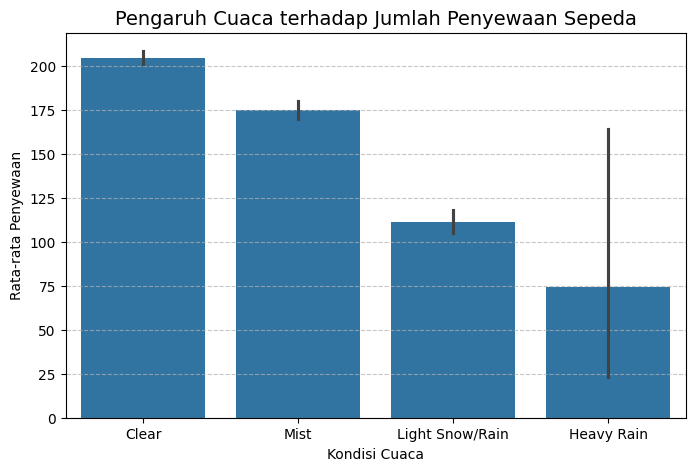

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x="weathersit",
    y="cnt",
    data=df,
    order=["Clear", "Mist", "Light Snow/Rain", "Heavy Rain"]
)

plt.title("Pengaruh Cuaca terhadap Jumlah Penyewaan Sepeda", fontsize=14)
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-rata Penyewaan")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### Pertanyaan 2:

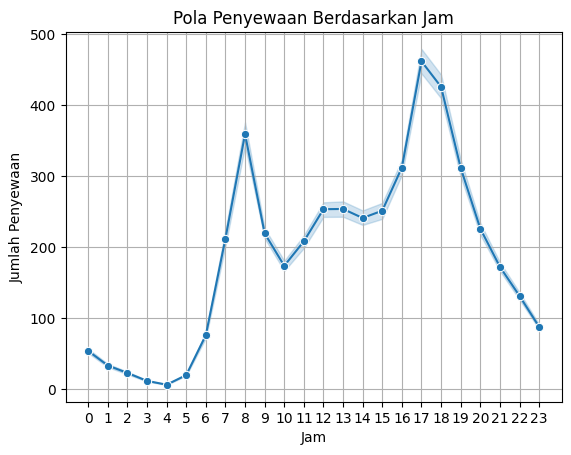

In [11]:
sns.lineplot(x="hr", y="cnt", data=df, marker="o")

plt.xticks(range(0, 24))
plt.grid(True)
plt.title("Pola Penyewaan Berdasarkan Jam")
plt.xlabel("Jam")
plt.ylabel("Jumlah Penyewaan")

plt.show()

## Analisis Lanjutan (Opsional)

In [12]:
df["day_type"] = df["workingday"].apply(lambda x: "Weekday" if x == 1 else "Weekend")

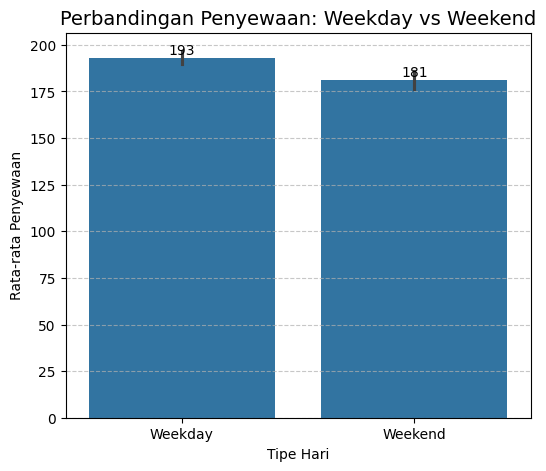

In [13]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    x="day_type",
    y="cnt",
    data=df,
    order=["Weekday", "Weekend"]
)

# Tambahin angka di atas bar
for i in ax.containers:
    ax.bar_label(i, fmt='%.0f')

plt.title("Perbandingan Penyewaan: Weekday vs Weekend", fontsize=14)
plt.xlabel("Tipe Hari")
plt.ylabel("Rata-rata Penyewaan")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kondisi cuaca sangat memengaruhi jumlah penyewaan sepeda, di mana cuaca cerah menghasilkan jumlah penyewaan tertinggi.

- **Conclusion pertanyaan 2:** Puncak penyewaan terjadi pada jam sibuk, yaitu sekitar pagi dan sore hari, yang kemungkinan berkaitan dengan aktivitas berangkat dan pulang kerja.

**Rekomendasi Action Item:**

1. Menyediakan lebih banyak sepeda saat cuaca cerah untuk mengoptimalkan permintaan.

2. Meningkatkan ketersediaan sepeda pada jam sibuk (07.00–09.00 dan 17.00–19.00).

